## Week 3: Clustering

- Clustering is an unsupervised ML technique used to group similar data points together.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [12]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

### Feature Selection
- For clustering annual income and spending score are selected because they are useful for customer segmentation. CustomerID was excluded because it is only identifier.

In [13]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

### Feature Scaling

- The selected numerical features are scaled so that both features contribute equally to the distance calculations used by K-means.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Determining the Number of Clusters

- The elbow method is used to identify a suitable num of clusters for K-means clustering.

In [19]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

### Elbow Method

- The WCSS value is plotted against different num of clusters to identify a suitable value of K.

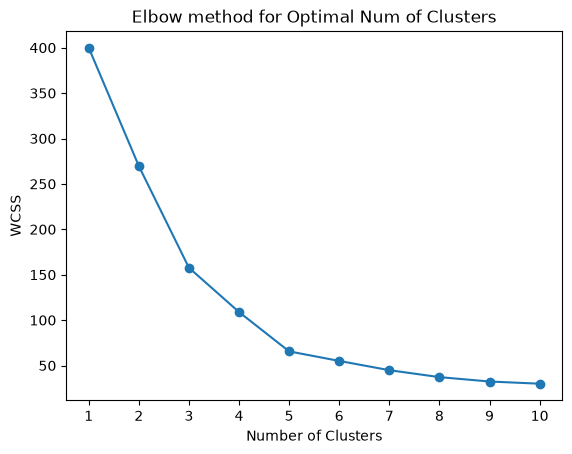

In [20]:
plt.plot(range(1,11),wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow method for Optimal Num of Clusters")
plt.xticks(range(1,11))
plt.show()

### Result
- The Elbow method indicates thaat 5 is suitable num of clusters.The WCSS decreases rapidly upto K = 5 and then begins to level off, suggesting thatadditional clusters provide smaller improvement.

### Silhouette Score Analysis

- The Silhouette Score is used to evaluate how well the data points fit within their assigned clusters and how clearly the clusters are separated.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Started from 2 because the sihouette score can't be calculated with only one cluster.

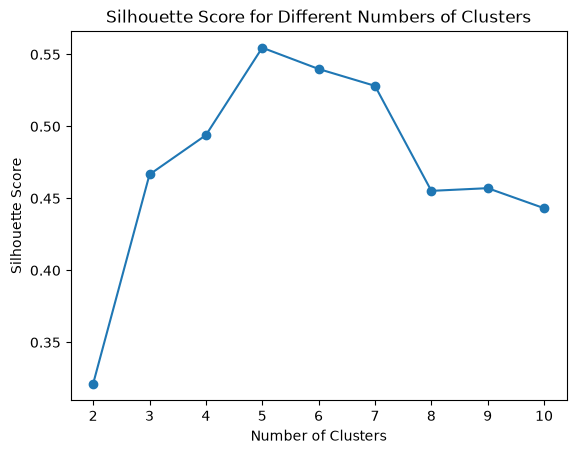

In [22]:
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range(2, 11))
plt.show()

### Result

- The highest Silhouette Score was obtained at K = 5. This supports the Elbow Method result, so 5 clusters were selected for the final K-Means model.

### K-Means Clustering

- Based on the Elbow Method and Silhouette Score analysis, K-Means clustering is applied using 5 clusters.

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

### Cluster Visualization

- The customers are visualized based on their Annual Income and Spending Score, with different colors representing the clusters identified by K-Means.

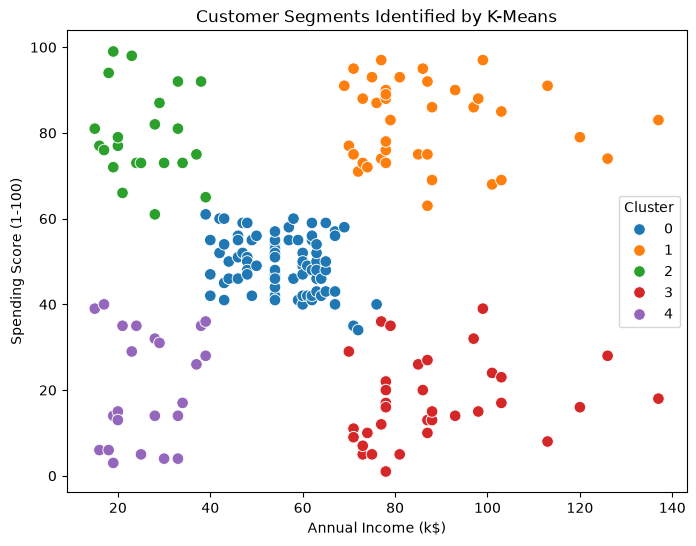

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=70
)

plt.title("Customer Segments Identified by K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

### Cluster Analysis

- After applying K-Means with 5 clusters, the next step is to analyze the characteristics of each customer segment. The cluster labels are compared using the original Annual Income and Spending Score values.

In [25]:
cluster_summary = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [26]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### Conclusion

This analysis used K-Means clustering to segment customers based on their Annual Income and Spending Score. The Elbow Method and Silhouette Score were used to determine a suitable number of clusters, with 5 clusters selected for the final model.

The clustering results identified distinct customer groups with different income and spending patterns. Overall, the analysis demonstrates how unsupervised learning can be used to identify meaningful patterns within customer data and support customer segmentation.